## 3 Relative prices and demand

### 3.1 Train prices, budget shares and quantities

We now let the price of train trips, p3, vary from 0.5 to 3.0, while p1, p2 and income are held fixed. We solve the model for each value of p3 for both the complements and substitutes calibration.

In [9]:
from types import SimpleNamespace

import numpy as np

from scipy import optimize

import matplotlib.pyplot as plt

from Consumer import ConsumerClass

/opt/anaconda3/lib/python3.14/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


Grid solution:
s1 = 0.5350701402805611
w  = 0.438877755511022
s2 = 0.20404737330372166
s3 = 0.26088248641571726
u  = 3.40167436585882

L-BFGS-B solution:
s1 = 0.5356233806953101
w  = 0.43947902810370126
s2 = 0.20408378532610758
s3 = 0.26029283397858227
u  = 3.401679875985606
Budget shares:
s1 = 0.5356233806953101
s2 = 0.20408378532610758
s3 = 0.26029283397858227

Sum of shares:
1.0

Quantities:
x1 = 5.356233806953101
x2 = 2.040837853261076
x3 = 1.7352855598572152
All shares between 0 and 1: True
Shares sum to 1: True
All quantities positive: True
Grid search:
s1 = 0.5355355355355356
w  = 0.4394394394394394
u  = 3.4016797975402664

L-BFGS-B:
s1 = 0.5356233806953101
w  = 0.43947902810370126
u  = 3.401679875985606
Difference in s1: 8.784515977455776e-05
Difference in w: 3.958866426184704e-05
Difference in utility: 7.844533955747579e-08
N = 50
s1 = 0.530612
w  = 0.448980
s2 = 0.210746
s3 = 0.258642
u  = 3.400748

N = 100
s1 = 0.535354
w  = 0.444444
s2 = 0.206510
s3 = 0.258137
u  = 3.401482

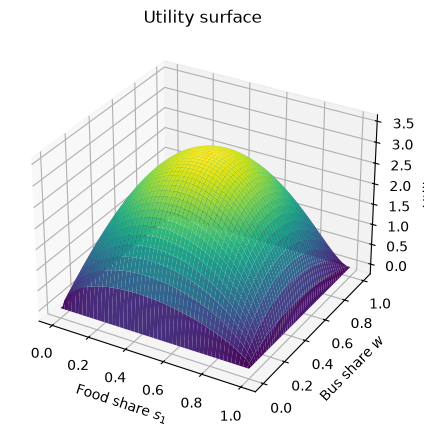

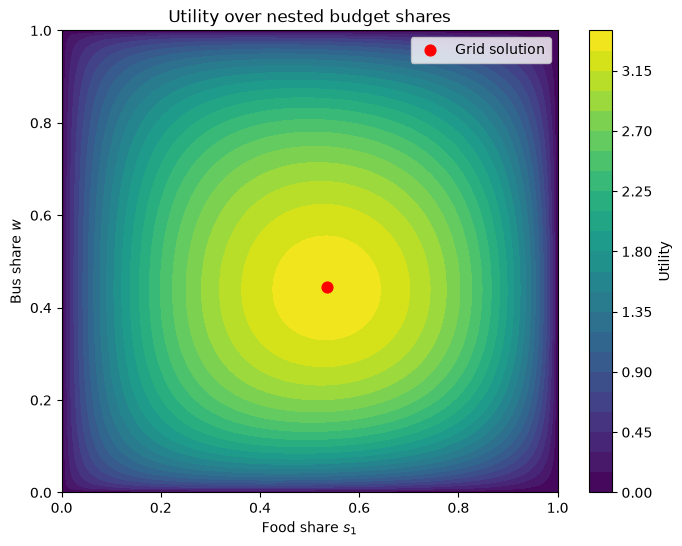

COMPLEMENTS
s1 = 0.5350701402805611
w  = 0.438877755511022
s2 = 0.20404737330372166
s3 = 0.26088248641571726
u  = 3.40167436585882

SUBSTITUTES
s1 = 0.5390781563126252
w  = 0.691382765531062
s2 = 0.31867341898225304
s3 = 0.14224842470512172
u  = 3.4850971386959047
L-BFGS-B solution
s1 = 0.5356233806953101
w  = 0.43947902810370126
s2 = 0.20408378532610758
s3 = 0.26029283397858227
u  = 3.401679875985606
Grid search
s1 = 0.5355355355355356
w  = 0.4394394394394394
u  = 3.4016797975402664

L-BFGS-B
s1 = 0.5356233806953101
w  = 0.43947902810370126
u  = 3.401679875985606

Differences
s1 difference = 8.784515977455776e-05
w difference  = 3.958866426184704e-05
u difference  = 7.844533955747579e-08


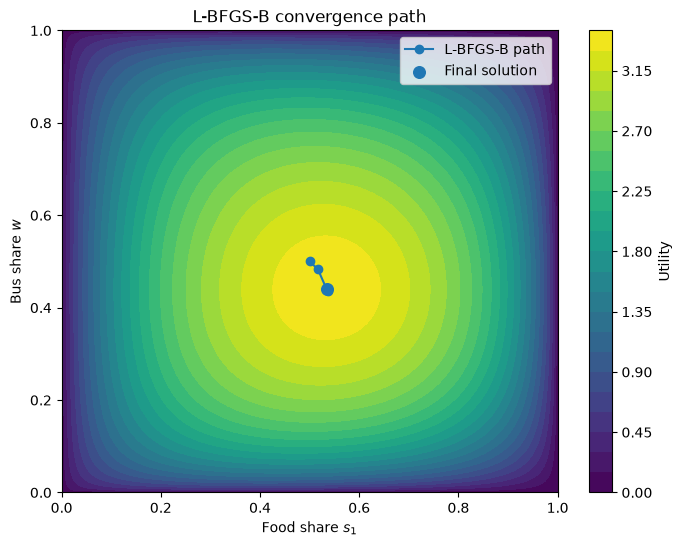

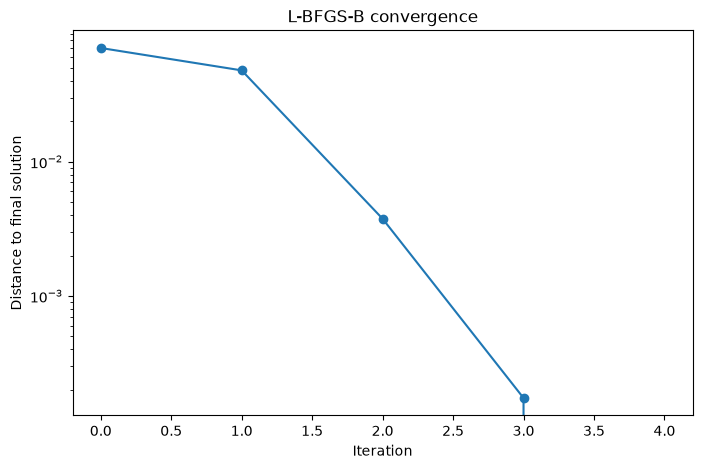

s0=[0.5, 0.5] -> s1=0.535623, w=0.439479, u=3.401680, iterations=4, success=True
s0=[0.0, 0.0] -> s1=0.535624, w=0.439478, u=3.401680, iterations=7, success=True
s0=[0.0, 1.0] -> s1=0.535624, w=0.439478, u=3.401680, iterations=9, success=True
s0=[1.0, 0.0] -> s1=0.999991, w=0.000000, u=0.000000, iterations=1, success=True
s0=[1.0, 1.0] -> s1=0.999991, w=1.000000, u=0.000000, iterations=1, success=True
s0=[0.25, 0.75] -> s1=0.535624, w=0.439479, u=3.401680, iterations=6, success=True
ftol=1e-04: s1=0.53560667, w=0.43965199, u=3.40167963, function evaluations=15
ftol=1e-08: s1=0.53562338, w=0.43947903, u=3.40167988, function evaluations=18
ftol=1e-12: s1=0.53562338, w=0.43947903, u=3.40167988, function evaluations=18
ftol=1e-16: s1=0.53562338, w=0.43947903, u=3.40167988, function evaluations=18
gtol=1e-02: s1=0.53560667, w=0.43965199, u=3.40167963, function evaluations=15
gtol=1e-05: s1=0.53562338, w=0.43947903, u=3.40167988, function evaluations=18
gtol=1e-08: s1=0.53562357, w=0.4394784

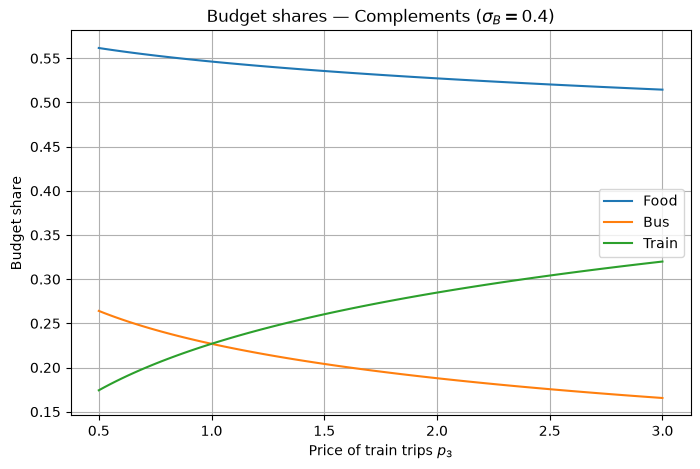

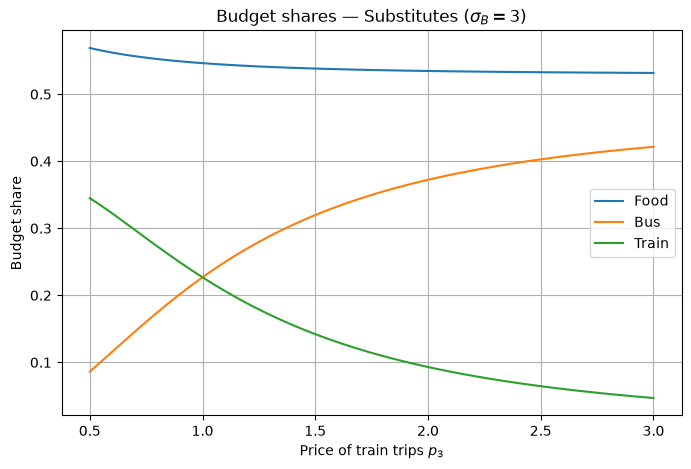

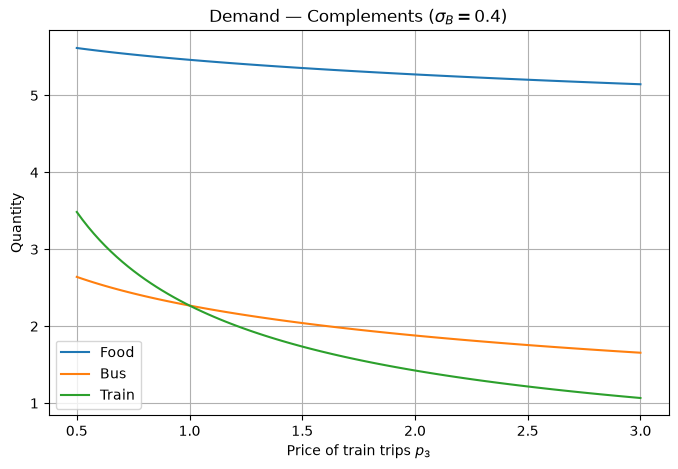

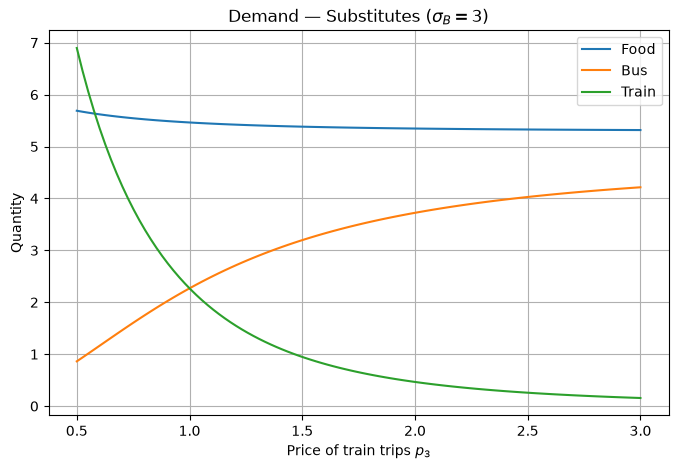

COMPLEMENTS
Food quantity:
Initial: 5.616600626540577
Final:   5.145198287042476
Change:  -0.47140233949810106

Bus quantity:
Initial: 2.64099427602805
Final:   1.6551321658009734
Change:  -0.9858621102270764

SUBSTITUTES
Food quantity:
Initial: 5.68902110077378
Final:   5.316987839764876
Change:  -0.37203326100890344

Bus quantity:
Initial: 0.8621956144294443
Final:   4.214711806379975
Change:  3.3525161919505306
Complements:
Food: -8.393018675220478 %
Bus: -37.32920283756819 %

Substitutes:
Food: -6.539495185881841 %
Bus: 388.8347534879367 %


In [10]:
p3_vec = np.linspace(0.5, 3.0, 100)
%run ModelProject1.3.ipynb
model = ConsumerClass()
model_sub = ConsumerClass(par={'sigma_B': 3.0})

First, we solve the model for the complements calibration. For each value of `p3`, we store the optimal budget shares and the corresponding quantities.

In [11]:
# Complements

s1_comp = []
s2_comp = []
s3_comp = []

x1_comp = []
x2_comp = []
x3_comp = []

for p3 in p3_vec:

    model.par.p3 = p3
    sol = model.solve()

    s1_comp.append(sol.s1)
    s2_comp.append(sol.s2)
    s3_comp.append(sol.s3)

    x1, x2, x3 = model.quantities(sol.s1, sol.w)

    x1_comp.append(x1)
    x2_comp.append(x2)
    x3_comp.append(x3)


We repeat the same procedure for the substitutes calibration. The only difference between the two models is the value of `sigma_B`.


In [12]:
# Substitutes

s1_sub = []
s2_sub = []
s3_sub = []

x1_sub = []
x2_sub = []
x3_sub = []

for p3 in p3_vec:

    model_sub.par.p3 = p3
    sol_sub = model_sub.solve()

    s1_sub.append(sol_sub.s1)
    s2_sub.append(sol_sub.s2)
    s3_sub.append(sol_sub.s3)

    x1, x2, x3 = model_sub.quantities(sol_sub.s1, sol_sub.w)

    x1_sub.append(x1)
    x2_sub.append(x2)
    x3_sub.append(x3)

We now plot the resulting budget shares and quantities as functions of the train price. This allows us to compare how the consumer responds under the two calibrations.

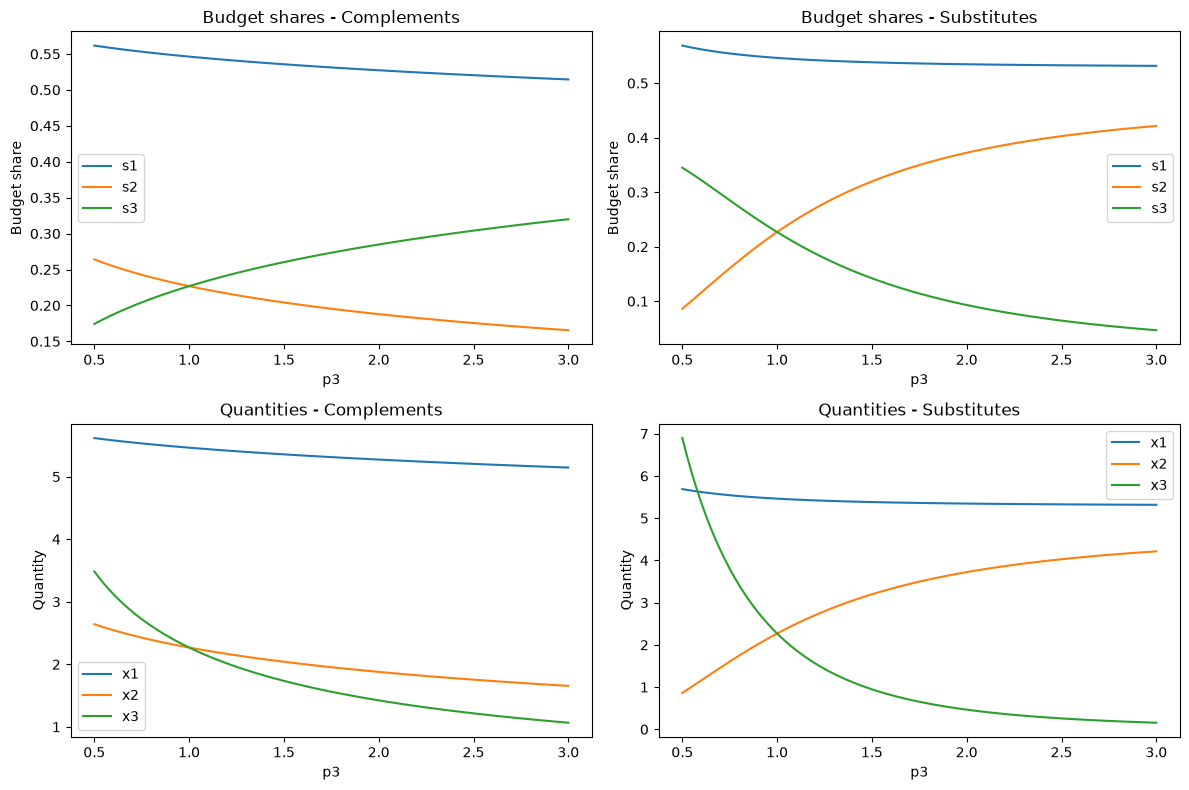

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(12,8))

# Budget shares - complements
ax[0,0].plot(p3_vec, s1_comp, label='s1')
ax[0,0].plot(p3_vec, s2_comp, label='s2')
ax[0,0].plot(p3_vec, s3_comp, label='s3')

ax[0,0].set_title('Budget shares - Complements')
ax[0,0].set_xlabel('p3')
ax[0,0].set_ylabel('Budget share')
ax[0,0].legend()


# Budget shares - substitutes
ax[0,1].plot(p3_vec, s1_sub, label='s1')
ax[0,1].plot(p3_vec, s2_sub, label='s2')
ax[0,1].plot(p3_vec, s3_sub, label='s3')

ax[0,1].set_title('Budget shares - Substitutes')
ax[0,1].set_xlabel('p3')
ax[0,1].set_ylabel('Budget share')
ax[0,1].legend()


# Quantities - complements
ax[1,0].plot(p3_vec, x1_comp, label='x1')
ax[1,0].plot(p3_vec, x2_comp, label='x2')
ax[1,0].plot(p3_vec, x3_comp, label='x3')

ax[1,0].set_title('Quantities - Complements')
ax[1,0].set_xlabel('p3')
ax[1,0].set_ylabel('Quantity')
ax[1,0].legend()


# Quantities - substitutes
ax[1,1].plot(p3_vec, x1_sub, label='x1')
ax[1,1].plot(p3_vec, x2_sub, label='x2')
ax[1,1].plot(p3_vec, x3_sub, label='x3')

ax[1,1].set_title('Quantities - Substitutes')
ax[1,1].set_xlabel('p3')
ax[1,1].set_ylabel('Quantity')
ax[1,1].legend()

plt.tight_layout()
plt.show()

The figures show that the response to a higher train price differs substantially between the two calibrations. The following questions examine these differences in more detail.

*3.1